In [1]:
from utils_task1 import RedditDataset

dataset = RedditDataset(path="Reddit")

batch_size = 2048
lr = 1e-4
num_epochs = 40

Numero di nodi:  232965
Numero di archi:  57307946
Dimensionalità delle features:  602
Di queste, le prime 300 l'embedding di Glove del titolo del post, le seconde 300 l'embedding di Glove medio di tutti i commenti
La feature 601 è lo score di reddit e la 602 è il numero di commenti
--------------------------------------------------------------------
Analisi della cardinalità delle classi e bilanciamento del dataset
classe  0 :  13101 -- 5.62%
classe  1 :   3550 -- 1.52%
classe  2 :   3302 -- 1.42%
classe  3 :  15181 -- 6.52%
classe  4 :   2322 -- 1.00%
classe  5 :   3597 -- 1.54%
classe  6 :   3952 -- 1.70%
classe  7 :   2138 -- 0.92%
classe  8 :  11187 -- 4.80%
classe  9 :   2246 -- 0.96%
classe 10 :   4928 -- 2.12%
classe 11 :   2964 -- 1.27%
classe 12 :   1696 -- 0.73%
classe 13 :   2731 -- 1.17%
classe 14 :   4854 -- 2.08%
classe 15 :  28272 -- 12.14%
classe 16 :   1003 -- 0.43%
classe 17 :   2639 -- 1.13%
classe 18 :  13999 -- 6.01%
classe 19 :  10308 -- 4.42%
classe 20 :   1596 

VALUTAZIONE DELLA DENSITÀ LOCALE
Nodo Target Centrale analizzato: 169537
Cardinalità del sotto-grafo: 200 nodi
Numero di archi locali interni: 5406


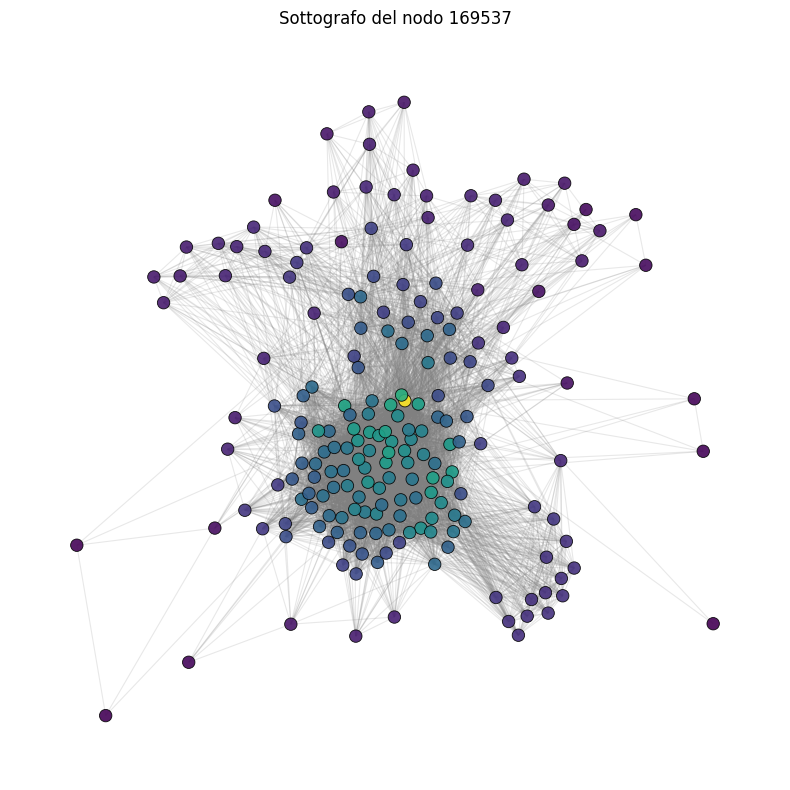

In [2]:
dataset.visualize(max_nodes=200)

In [3]:
train_loader, val_loader, test_loader = dataset.get_node_loaders(batch_size=batch_size)

In [4]:
import torch
from utils_task1 import train_loop, evaluate

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Inizio Task 1 su dispositivo: {device}")
data = dataset.dataset
stats = dataset.stats

# Calcolo dei pesi inversamente proporzionali alla frequenza di ciascuna classe per bilanciare la loss durante l'addestramento
labels_train = data.y[data.train_mask]
conteggi = torch.bincount(labels_train)
pesi_classi = 1.0 / conteggi.float()
pesi_classi = pesi_classi / pesi_classi.sum()
pesi_classi = pesi_classi.to(device)

Inizio Task 1 su dispositivo: cuda


Primo tentativo con GCNConv

In [9]:
from utils_task1 import GCNmodel

model = GCNmodel(
    in_channels=stats.num_features, hidden_size=256, out_channels=len(stats.classes)
).to(device)

best_model_path = "best_model_task1_GCN.pth"

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.CrossEntropyLoss(weight=pesi_classi)
scaler = torch.amp.GradScaler()

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path=best_model_path,
    scaler=scaler,
    stats=stats,
)


--- AVVIO LOOP DI ADDESTRAMENTO ---


Epoca: 01/40 | Loss Train: 2.02 | Val Loss: 0.71 | Val F1 weighted: 0.90 | Val Precision: 0.91 | Val Recall: 0.90 |Val Balanced Acc: 0.85
  → Nuovo best model salvato (val_loss=0.7056)


Epoca: 02/40 | Loss Train: 0.79 | Val Loss: 0.51 | Val F1 weighted: 0.92 | Val Precision: 0.92 | Val Recall: 0.92 |Val Balanced Acc: 0.88
  → Nuovo best model salvato (val_loss=0.5106)


Epoca: 03/40 | Loss Train: 0.63 | Val Loss: 0.46 | Val F1 weighted: 0.92 | Val Precision: 0.93 | Val Recall: 0.92 |Val Balanced Acc: 0.88
  → Nuovo best model salvato (val_loss=0.4624)


Epoca: 04/40 | Loss Train: 0.58 | Val Loss: 0.45 | Val F1 weighted: 0.92 | Val Precision: 0.92 | Val Recall: 0.92 |Val Balanced Acc: 0.88
  → Nuovo best model salvato (val_loss=0.4504)


...

Epoca: 21/40 | Loss Train: 0.43 | Val Loss: 0.37 | Val F1 weighted: 0.93 | Val Precision: 0.93 | Val Recall: 0.93 |Val Balanced Acc: 0.90
  → No improvement (1/5)


Epoca: 22/40 | Loss Train: 0.43 | Val Loss: 0.38 | Val F1 weighted: 0.93 | Val Precision: 0.93 | Val Recall: 0.93 |Val Balanced Acc: 0.90
  → No improvement (2/5)


Epoca: 23/40 | Loss Train: 0.43 | Val Loss: 0.37 | Val F1 weighted: 0.93 | Val Precision: 0.93 | Val Recall: 0.93 |Val Balanced Acc: 0.90
  → No improvement (3/5)


Epoca: 24/40 | Loss Train: 0.43 | Val Loss: 0.37 | Val F1 weighted: 0.93 | Val Precision: 0.93 | Val Recall: 0.93 |Val Balanced Acc: 0.90
  → No improvement (4/5)


Epoca: 25/40 | Loss Train: 0.42 | Val Loss: 0.38 | Val F1 weighted: 0.93 | Val Precision: 0.93 | Val Recall: 0.93 |Val Balanced Acc: 0.90
  → No improvement (5/5)

Early stopping attivato all'epoca 25.


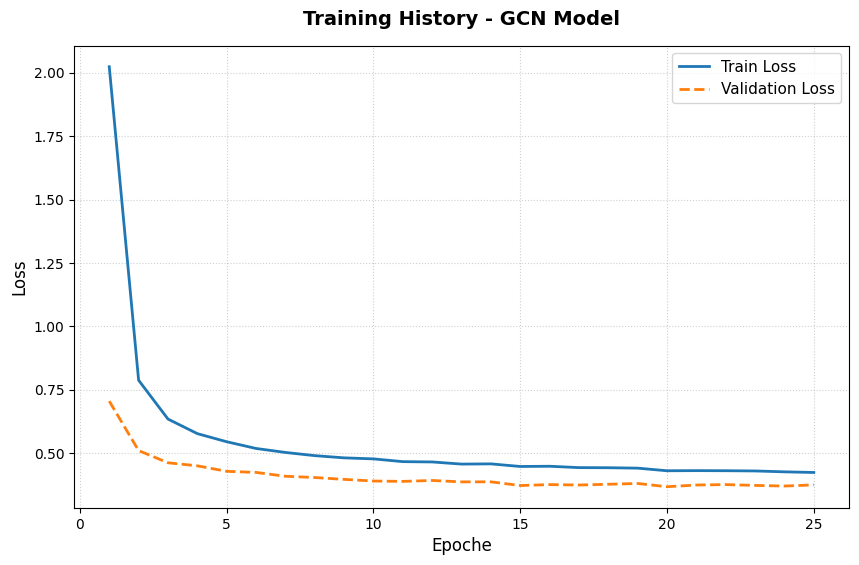

In [10]:
from utils_task1 import plot_history

plot_history(history, title="Training History - GCN Model")

In [15]:
# ====================================================================
# VALUTAZIONE FINALE SUL TEST SET
# ====================================================================
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("\n--- CARICAMENTO MIGLIOR MODELLO PER IL TEST ---")
model.load_state_dict(torch.load(best_model_path))

print("\n--- VERIFICA METRICHE FINALI SUL TEST SET ---")
test_stats = evaluate(model, test_loader, loss_fn, device, test=True)

print(
    f"Test Loss: {test_stats.avg_loss:.4f} |"
    f"Test F1-weighted: {test_stats.f1_weighted:.2f} |"
    f"Test Balanced Acc: {test_stats.balanced_acc:.2f} |"
    f"Test Precision-weighted: {test_stats.precision_weighted:.2f} |"
    f"Test Recall-weighted: {test_stats.recall_weighted:.2f} |"
)


--- CARICAMENTO MIGLIOR MODELLO PER IL TEST ---

--- VERIFICA METRICHE FINALI SUL TEST SET ---


Test Loss: 0.3797 |Test F1-weighted: 0.93 |Test Balanced Acc: 0.90 |Test Precision-weighted: 0.93 |Test Recall-weighted: 0.93 |


Tentativo con SAGEConv

In [4]:
from utils_task1 import SAGEConvModel

model = SAGEConvModel(
    in_channels=stats.num_features, hidden_size=256, out_channels=len(stats.classes)
).to(device)

best_model_path = "best_model_task1_SAGE.pth"

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.CrossEntropyLoss(weight=pesi_classi)
scaler = torch.amp.GradScaler()

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path=best_model_path,
    scaler=scaler,
    stats=stats,
)


--- AVVIO LOOP DI ADDESTRAMENTO ---


Epoca: 01/40 | Loss Train: 2.52 | Val Loss: 1.00 | Val F1 weighted: 0.80 | Val Precision: 0.82 | Val Recall: 0.80 |Val Balanced Acc: 0.77
  → Nuovo best model salvato (val_loss=0.9986)


Epoca: 02/40 | Loss Train: 1.03 | Val Loss: 0.54 | Val F1 weighted: 0.91 | Val Precision: 0.91 | Val Recall: 0.91 |Val Balanced Acc: 0.87
  → Nuovo best model salvato (val_loss=0.5392)


Epoca: 03/40 | Loss Train: 0.70 | Val Loss: 0.43 | Val F1 weighted: 0.92 | Val Precision: 0.93 | Val Recall: 0.92 |Val Balanced Acc: 0.90
  → Nuovo best model salvato (val_loss=0.4323)


Epoca: 04/40 | Loss Train: 0.57 | Val Loss: 0.38 | Val F1 weighted: 0.93 | Val Precision: 0.93 | Val Recall: 0.93 |Val Balanced Acc: 0.90
  → Nuovo best model salvato (val_loss=0.3809)


...

Epoca: 36/40 | Loss Train: 0.20 | Val Loss: 0.22 | Val F1 weighted: 0.95 | Val Precision: 0.96 | Val Recall: 0.95 |Val Balanced Acc: 0.94
  → No improvement (2/5)


Epoca: 37/40 | Loss Train: 0.19 | Val Loss: 0.21 | Val F1 weighted: 0.95 | Val Precision: 0.96 | Val Recall: 0.95 |Val Balanced Acc: 0.94
  → Nuovo best model salvato (val_loss=0.2149)


Epoca: 38/40 | Loss Train: 0.19 | Val Loss: 0.22 | Val F1 weighted: 0.95 | Val Precision: 0.96 | Val Recall: 0.95 |Val Balanced Acc: 0.94
  → No improvement (1/5)


Epoca: 39/40 | Loss Train: 0.19 | Val Loss: 0.22 | Val F1 weighted: 0.95 | Val Precision: 0.96 | Val Recall: 0.95 |Val Balanced Acc: 0.94
  → No improvement (2/5)


Epoca: 40/40 | Loss Train: 0.19 | Val Loss: 0.21 | Val F1 weighted: 0.96 | Val Precision: 0.96 | Val Recall: 0.96 |Val Balanced Acc: 0.94
  → Nuovo best model salvato (val_loss=0.2115)


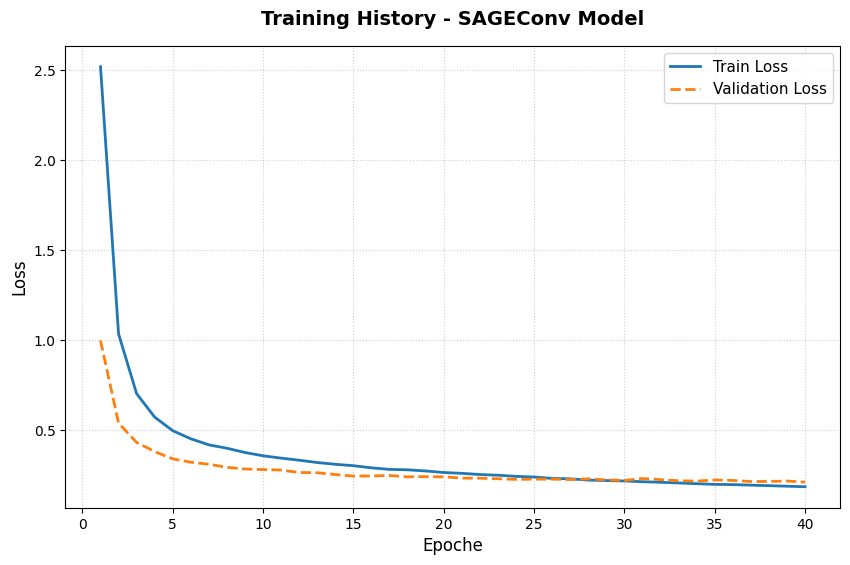

In [5]:
from utils_task1 import plot_history

plot_history(history, title="Training History - SAGEConv Model")

In [6]:
# ====================================================================
# VALUTAZIONE FINALE SUL TEST SET
# ====================================================================
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("\n--- CARICAMENTO MIGLIOR MODELLO PER IL TEST ---")
model.load_state_dict(torch.load(best_model_path))

print("\n--- VERIFICA METRICHE FINALI SUL TEST SET ---")
test_stats = evaluate(model, test_loader, loss_fn, device, test=True)

print(
    f"Test Loss: {test_stats.avg_loss:.4f} |"
    f"Test F1-weighted: {test_stats.f1_weighted:.2f} |"
    f"Test Balanced Acc: {test_stats.balanced_acc:.2f} |"
    f"Test Precision-weighted: {test_stats.precision_weighted:.2f} |"
    f"Test Recall-weighted: {test_stats.recall_weighted:.2f} |"
)


--- CARICAMENTO MIGLIOR MODELLO PER IL TEST ---

--- VERIFICA METRICHE FINALI SUL TEST SET ---


Test Loss: 0.2399 |Test F1-weighted: 0.95 |Test Balanced Acc: 0.94 |Test Precision-weighted: 0.96 |Test Recall-weighted: 0.95 |


Tentativo con GATConv

In [5]:
from utils_task1 import GATModel

model = GATModel(
    in_channels=stats.num_features, hidden_size=256, out_channels=len(stats.classes)
).to(device)

best_model_path = "best_model_task1_GAT.pth"

optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
loss_fn = torch.nn.CrossEntropyLoss(weight=pesi_classi)
scaler = torch.amp.GradScaler()

history = train_loop(
    num_epochs=num_epochs,
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    best_model_path=best_model_path,
    scaler=scaler,
    stats=stats,
)


--- AVVIO LOOP DI ADDESTRAMENTO ---


c:\Users\giaco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoca: 01/40 | Loss Train: 3.51 | Val Loss: 3.08 | Val F1 weighted: 0.25 | Val Precision: 0.57 | Val Recall: 0.32 |Val Balanced Acc: 0.31
  → Nuovo best model salvato (val_loss=3.0839)


c:\Users\giaco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoca: 02/40 | Loss Train: 2.65 | Val Loss: 2.02 | Val F1 weighted: 0.61 | Val Precision: 0.69 | Val Recall: 0.62 |Val Balanced Acc: 0.57
  → Nuovo best model salvato (val_loss=2.0236)


...

Epoca: 36/40 | Loss Train: 0.31 | Val Loss: 0.29 | Val F1 weighted: 0.95 | Val Precision: 0.95 | Val Recall: 0.95 |Val Balanced Acc: 0.93
  → No improvement (1/5)


Epoca: 37/40 | Loss Train: 0.31 | Val Loss: 0.29 | Val F1 weighted: 0.95 | Val Precision: 0.95 | Val Recall: 0.95 |Val Balanced Acc: 0.93
  → No improvement (2/5)


Epoca: 38/40 | Loss Train: 0.31 | Val Loss: 0.28 | Val F1 weighted: 0.95 | Val Precision: 0.95 | Val Recall: 0.95 |Val Balanced Acc: 0.93
  → Nuovo best model salvato (val_loss=0.2797)


Epoca: 39/40 | Loss Train: 0.30 | Val Loss: 0.28 | Val F1 weighted: 0.95 | Val Precision: 0.95 | Val Recall: 0.95 |Val Balanced Acc: 0.93
  → Nuovo best model salvato (val_loss=0.2796)


Epoca: 40/40 | Loss Train: 0.30 | Val Loss: 0.28 | Val F1 weighted: 0.95 | Val Precision: 0.95 | Val Recall: 0.95 |Val Balanced Acc: 0.93
  → No improvement (1/5)


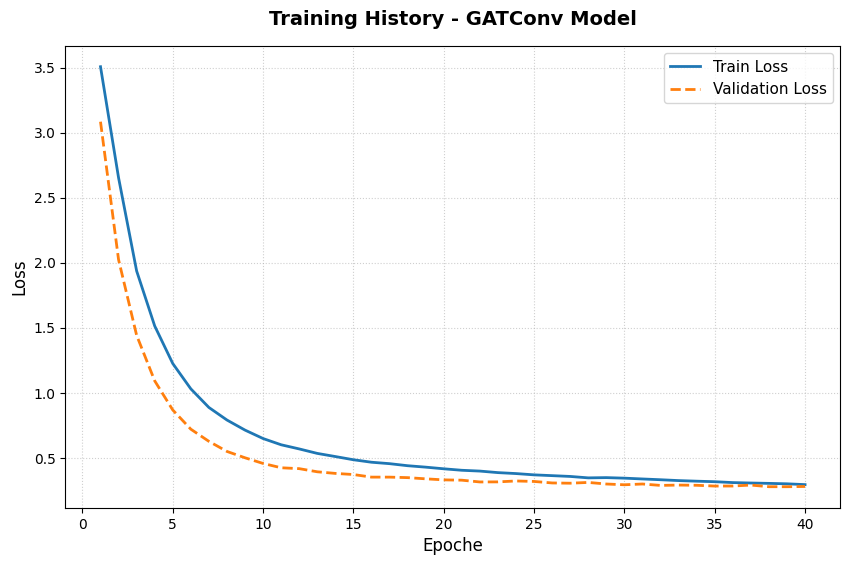

In [6]:
from utils_task1 import plot_history

plot_history(history, title="Training History - GATConv Model")

In [7]:
# ====================================================================
# VALUTAZIONE FINALE SUL TEST SET
# ====================================================================
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print("\n--- CARICAMENTO MIGLIOR MODELLO PER IL TEST ---")
model.load_state_dict(torch.load(best_model_path))

print("\n--- VERIFICA METRICHE FINALI SUL TEST SET ---")
test_stats = evaluate(model, test_loader, loss_fn, device, test=True)

print(
    f"Test Loss: {test_stats.avg_loss:.4f} |"
    f"Test F1-weighted: {test_stats.f1_weighted:.2f} |"
    f"Test Balanced Acc: {test_stats.balanced_acc:.2f} |"
    f"Test Precision-weighted: {test_stats.precision_weighted:.2f} |"
    f"Test Recall-weighted: {test_stats.recall_weighted:.2f} |"
)


--- CARICAMENTO MIGLIOR MODELLO PER IL TEST ---

--- VERIFICA METRICHE FINALI SUL TEST SET ---


Test Loss: 0.3139 |Test F1-weighted: 0.95 |Test Balanced Acc: 0.93 |Test Precision-weighted: 0.95 |Test Recall-weighted: 0.95 |
